In [225]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/titanic.csv'

df = pd.read_csv(path)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [226]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [227]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df = df.dropna(subset=['Embarked'])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [228]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex_encoded'] = le.fit_transform(df['Sex'])
df['Embarked_encoded'] = le.fit_transform(df['Embarked'])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_encoded,Embarked_encoded
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,2


In [229]:
df=df.drop(['PassengerId','Name','Sex','Ticket','Cabin','Embarked'],axis=1)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_encoded
0,0,3,22.0,1,0,7.2500,1,2
1,1,1,38.0,1,0,71.2833,0,0
2,1,3,26.0,0,0,7.9250,0,2
3,1,1,35.0,1,0,53.1000,0,2
4,0,3,35.0,0,0,8.0500,1,2


In [230]:
y=df['Survived']
print(y.value_counts())
y

Survived
0    549
1    340
Name: count, dtype: int64


,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [231]:
X=df.drop('Survived',axis=1)
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_encoded
0,3,22.0,1,0,7.2500,1,2
1,1,38.0,1,0,71.2833,0,0
2,3,26.0,0,0,7.9250,0,2
3,1,35.0,1,0,53.1000,0,2
4,3,35.0,0,0,8.0500,1,2


In [232]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [233]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_lr = LogisticRegression(random_state=0)
clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))
print (confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
0.7134831460674157
[[84 21]
 [30 43]]


In [234]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y_test, pred_dt))
print (confusion_matrix(y_test, pred_dt))


--- Decision Tree Classifier ---
0.7808988764044944
[[90 15]
 [24 49]]


In [235]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print ("\n--- Radom Forest ---")
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
print(accuracy_score(y_test,pred))
print (confusion_matrix(y_test, pred))


--- Radom Forest ---
0.7584269662921348
[[88 17]
 [26 47]]


In [236]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=6)

In [237]:
y_pred = knn.predict(X_test)

from sklearn import metrics
scores = metrics.accuracy_score(y_test, y_pred)
print(scores)

0.6853932584269663


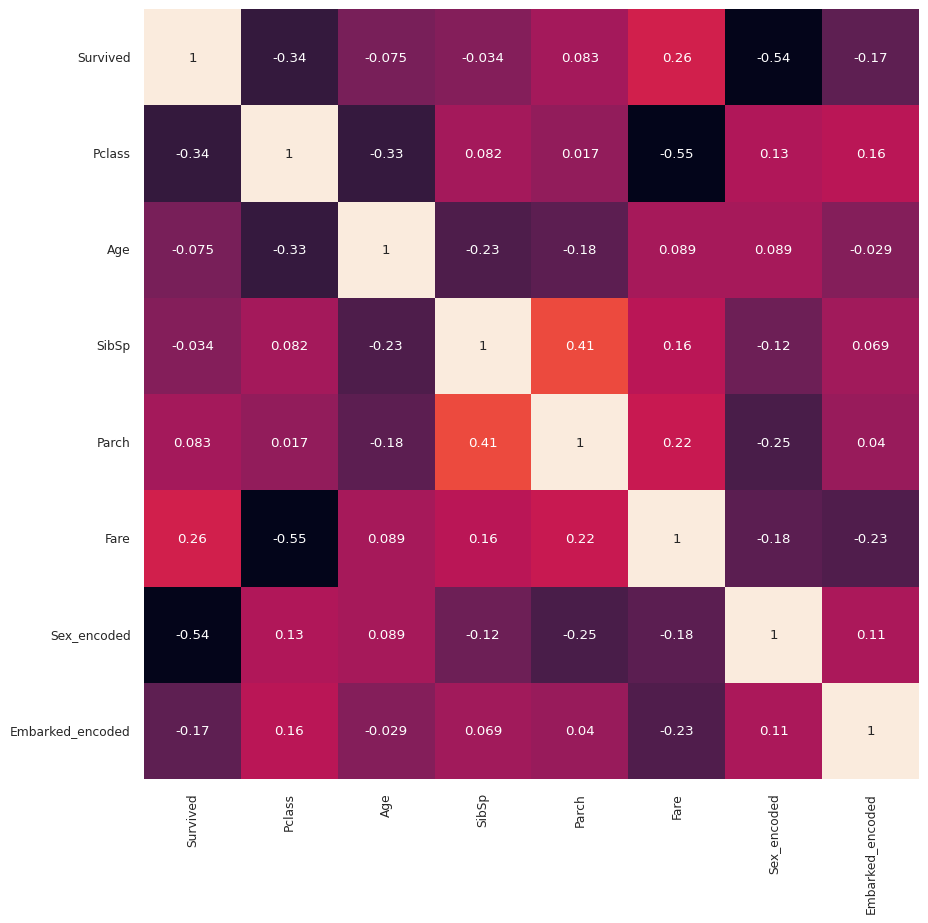

In [238]:
import matplotlib.pyplot as plt
import seaborn as sns

df_corr=df.corr()

plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [239]:
y2=df['Survived']

In [240]:
X2=df.drop(['Survived','Age','SibSp','Parch'],axis=1)
X2.head()

,Pclass,Fare,Sex_encoded,Embarked_encoded
0,3,7.2500,1,2
1,1,71.2833,0,0
2,3,7.9250,0,2
3,1,53.1000,0,2
4,3,8.0500,1,2


In [241]:
from sklearn.model_selection import train_test_split
X2_train,X2_test, y2_train,y2_test = train_test_split(X2,y2,test_size=0.2,random_state=0)

In [247]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_lr2 = LogisticRegression(random_state=0)
clf_lr2.fit(X2_train, y2_train)

pred_lr2 = clf_lr2.predict(X2_test)

print ("\n--- Logistic Regression Classifier ---")
print ("--- Pclass, Fare, Sex, Embarked  ---")
print (accuracy_score(y2_test, pred_lr2))
print (confusion_matrix(y2_test, pred_lr2))


--- Logistic Regression Classifier ---
--- Pclass, Fare, Sex, Embarked  ---
0.7078651685393258
[[80 25]
 [27 46]]


In [243]:
y3=df['Survived']

In [244]:
X3=X2.drop(['Fare','Embarked_encoded'],axis=1)
X3.head()

,Pclass,Sex_encoded
0,3,1
1,1,0
2,3,0
3,1,0
4,3,1


In [245]:
from sklearn.model_selection import train_test_split
X3_train,X3_test, y3_train,y3_test = train_test_split(X3,y3,test_size=0.2,random_state=0)

In [248]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_lr3 = LogisticRegression(random_state=0)
clf_lr3.fit(X3_train, y3_train)

pred_lr3 = clf_lr3.predict(X3_test)

print ("\n--- Logistic Regression Classifier ---")
print ("--- Pclass, Sex  ---")
print (accuracy_score(y3_test, pred_lr3))
print (confusion_matrix(y3_test, pred_lr3))


--- Logistic Regression Classifier ---
--- Pclass, Sex  ---
0.7191011235955056
[[85 20]
 [30 43]]
